## Results of Host Prediction
### Dataset: EMBL mapping, Vertebrates, Non-IDV

**Models**: FNN, CNN, RNN, LSTM, TF

**Positional Embedding**: Sin-Cos

**Maximum Sequence Length**: 1036

**Classification**: Multi-class

**\# classes**: 5

**\# train samples** = 

**\# validation samples** = 

**\# test samples** = 

In [9]:
import seaborn

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [10]:
seaborn.__version__

'0.13.2'

In [11]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebo

In [12]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [13]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        df.fillna(0, inplace=True)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

In [14]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 3]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.35, 1), ncol=5, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=600)
    plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

Read output BLAST-Genus split = (44793, 10)
Read output HAVEN-Genus split = (18473, 7)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


<Figure size 640x480 with 0 Axes>

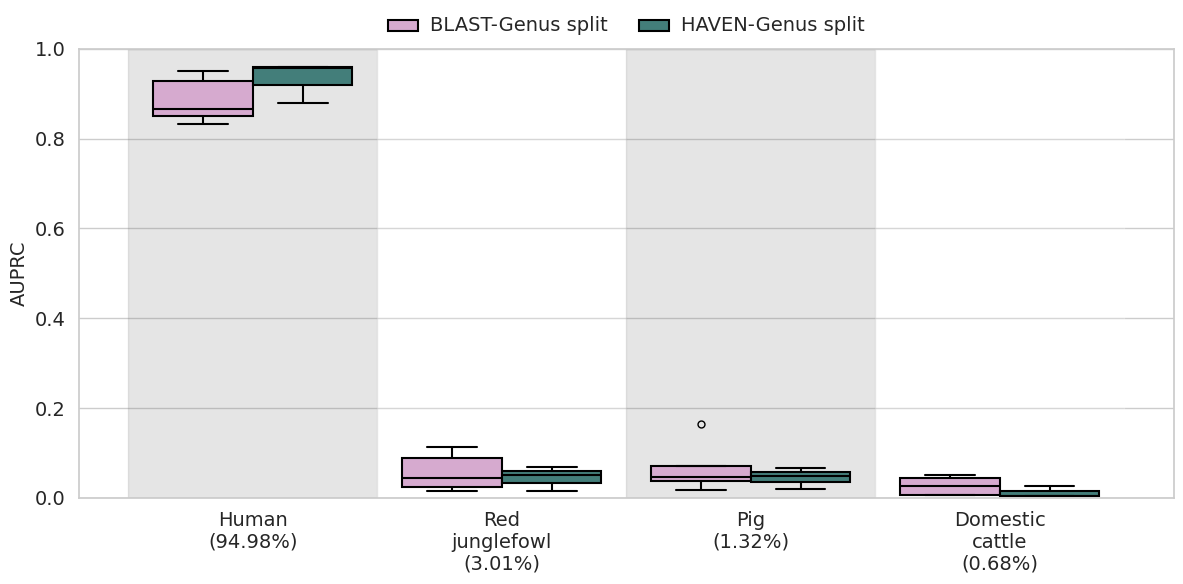

In [24]:
output_filepaths = {
    "BLAST-Genus split": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_virus_genus_host_species_vertebrates_non_idv_t0.01_c4_seq_len_in_99percentile/20260326/host_multi/virus_genus_split/homology/virus_host_tax_id_multi_blast_blast_output.csv"),
    "HAVEN-Genus split": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output.csv")
}

classes = ["Human", "Pig", "Domestic cattle", "Red junglefowl"]
classwise_auprc_analysis(output_filepaths, None)

In [22]:
def combine_output_files(output_filepath_template, itrs, output_filename):
    dfs = []
    for itr in itrs:
        df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", output_filepath_template.format(itr=itr)), index_col=0)
        df["itr"] = int(itr)
        dfs.append(df)
    pd.concat(dfs).to_csv(output_filename)

In [23]:
combine_output_files(os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_itr{itr}_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output_itr0.csv"),
                     [1, 2, 3],
                    os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output.csv"))